In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[9]:

#Libraries needed
import umap.umap_ as umap
import argparse
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import astropy.io.fits as pf
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr               
from sklearn.semi_supervised import LabelSpreading, LabelPropagation

sns.set(style='white', rc={'figure.figsize':(12,8)})

parser = argparse.ArgumentParser()
parser.add_argument("-norm", "--normalization", type=int, required=False, default=1,
                    help = "Normalize the dataframes before joining them (0=No, 1=Yes)")
parser.add_argument("-n", "--n_components", type=int, required=False, default=2,
                    help = "Number of components for UMAP")


args, unknown = parser.parse_known_args()
norm = args.normalization
NC = args.n_components

In [2]:
print('----------------------------')
print('Load latent space...')

#grb name files
grb_names = np.load(f'./name_list_minval5_weightedLoss_Mic_test+train.npy', allow_pickle=True)
hl_1 = np.load(f'./l_space_vector_minval5_weightedLoss_Mic_200_long_test+train.npy'  )
hl_2 = np.load(f'./l_space_vector_minval5_weightedLoss_Mic_250_medium_test+train.npy')
hl_3 = np.load(f'./l_space_vector_minval5_weightedLoss_Mic_250_short_test+train.npy' )


# Known GRBs
GRB_BNS = ['GRB080905499', 'GRB150101641', 'GRB160821937', 'GRB170817529']
GRB_MGF = ['GRB200415367', 'GRB180128215']
GRB_LBNS = ['GRB230307656', 'GRB211211549']
GRB_CCSN = ['GRB081007224', 'GRB090618353', 'GRB091127976', 'GRB101219686', 
            'GRB111228657', 'GRB120729456', 'GRB130215063', 'GRB130427324', 
            'GRB130702004', 'GRB140606133', 'GRB171010792', 'GRB180728728', 
            'GRB190114873', 'GRB190829830', 'GRB211023546', 'GRB221009553', 'GRB200826187']
GRB_MGF_TEST = ['GRB231115650']
GRB_CCSN_TEST = ['GRB230812790']

grb_dict = {'name': grb_names,
            'filltest':np.ones(len(grb_names)),
            # '3dumap1': grb_umap3d[0],
            # '3dumap2': grb_umap3d[1],
            # '3dumap3': grb_umap3d[2],
            # '2dumap1': grb_umap2d[0],
            # '2dumap2': grb_umap2d[1],
            # 'msize': markersize,
            'label': np.full( len(grb_names), -1)}
grb_df = pd.DataFrame.from_dict(grb_dict)

print()
print('-------------- UMAP parameters --------------')

#All UMAP parameters
n_components_list=[2] #[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]
NN = 30
MD =0.
LOC_CON = 0.5
NEPOCHS = 1000
LR = 0.001
M = 'euclidean'

#Print parameters
print('n_components: ', n_components_list)
print('n_neighbors:', NN)
print('min_dist:', MD)
print('local_connectivity:', LOC_CON)
print('metric:', M)

#Check file lengths
print()
print('-------------- Checking File Lengths --------------')
print('check same length:', len(hl_1),len(hl_2), len(hl_3))


#Trustworthiness test parameters
print()
print('-------------- Trustworthiness parameters --------------')
NP = 1

#Print parameters
print('num_permutations:', NP)

significativity_vec=[]
dub_vec=[]
unlabeled_vec=[]
sig_vec_dubious=[]

----------------------------
Load latent space...

-------------- UMAP parameters --------------
n_components:  [2]
n_neighbors: 30
min_dist: 0.0
local_connectivity: 0.5
metric: euclidean

-------------- Checking File Lengths --------------
check same length: 2512 2512 2512

-------------- Trustworthiness parameters --------------
num_permutations: 1


In [3]:
#Definitions for the code:

#Normalize the dataset for use
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

hl_1, hl_2, hl_3 = normalize(hl_1), normalize(hl_2), normalize(hl_3)
        
# Concatenate into final latent space
dataset = np.concatenate((hl_1, hl_2, hl_3), axis=1)

print('----------------------------')
print('Normalize Dataset...')
        
print("Number of GRBs:", dataset.shape[0])
print("Dimensionality before UMAP:", dataset.shape[1])

#Evaluate the trustworthiness of the reduction

#show_plot=1 if reliability results are desired, if not show_plot=0  
show_plot=1 

# Define the "neighborhood" of an event.
n_samples = dataset.shape[0]
k = int(n_samples/2)

def get_trustworthiness(hl, embedding):
    # Evaluate the distance between events in the original space and in the embedded space.
    dist_orig = pairwise_distances(hl)
    dist_latent = pairwise_distances(embedding)
    
    # In the following cicle, for each event, evaluate the correlation of the k nearest neighbors in the original and embedded space.
    correlation_vector = np.zeros(n_samples) # One value for each event 
    
    for i in range(n_samples):
        # For the ith event, identify the closest k events in the original space...
        closest_orig_indices = np.argsort(dist_orig[i])[1:k+1]
        # ... and the closest k in the embedded space
        closest_latent_indices = np.argsort(dist_latent[i])[1:k+1]
        # Evaluate the distances of these events in the final embedded space
        closest_orig_distances = dist_latent[i][closest_orig_indices]
        closest_latent_distances = dist_latent[i][closest_latent_indices]
        # Find the Pearson correlation between the distance vectors
        correlation, _ = pearsonr(closest_orig_distances, closest_latent_distances)
        correlation_vector[i] = correlation
        # One distribution is not statistically significant enough, need to compute it several times.
        
    max_data_values= np.mean(correlation_vector)
    num_permutations = NP
    
    # Define our final vector: which is filled later
    null_distributions = np.zeros((num_permutations, n_samples))

    #Loop through number of permutations
    #Dataset with no meaningful representation
    for perm in range(num_permutations):
        permuted_original = np.zeros_like(hl)
        n_rows, n_cols = permuted_original.shape
        for col in range(n_cols):
            vals = np.sort(hl[:, col])
            u = np.random.rand(n_rows)
            permuted_original[:, col] = np.interp(
                u,
                np.linspace(0, 1, len(vals)),
                vals
            )
       
        # Generate the UMAP embedding of the permuted dataset
        reducer = umap.UMAP(n_neighbors=NN, min_dist=MD, n_components=embedding.shape[1],
                            metric='euclidean', n_epochs=NEPOCHS, local_connectivity=LOC_CON,
                            learning_rate=LR, random_state=perm)
        permuted_latent = reducer.fit_transform(permuted_original)
        
        # Calculate the same correlation that was evaluated for the actual dataset, but this time for the permuted one
        dist_orig = pairwise_distances(permuted_original)
        dist_latent = pairwise_distances(permuted_latent)
        for i in range(n_samples):
            closest_orig_indices = np.argsort(dist_orig[i])[1:k+1]
            closest_latent_indices = np.argsort(dist_latent[i])[1:k+1]
            null_distributions[perm,i], _ = pearsonr(dist_latent[i][closest_orig_indices],
                                                 dist_latent[i][closest_latent_indices])

    # Flatten the null distribution: performed more than one permutation only for statistical reasons.
    null_distributions = null_distributions.flatten()
    
    # Evaluate the 95th and 5th percentile of the null distribution.
    percentile_95 = np.percentile(null_distributions, 95)
    percentile_5 = np.percentile(null_distributions, 5)
    max_null_values = percentile_5

    if show_plot==1:
        # Plot the null and the actual correlation distributions.
        bins = 150
        plt.figure(figsize=(8,6))
        plt.hist(null_distributions, bins=bins, density=True, histtype='step',
                 color='black', linewidth=2, label="Null distribution")
        plt.hist(correlation_vector, bins=bins, density=True, histtype='step',
                 color='blue', linewidth=2, label="Real embedding")
        plt.axvline(percentile_5, color='red', linestyle='--', label="5th percentile")
        plt.axvline(percentile_95, color='green', linestyle='--', label="95th percentile")
        plt.ylim(0,7)
        plt.xlim(-0.1,1)
        plt.xlabel("Pearson Correlation")
        plt.ylabel("Density")
        plt.legend()
        plt.title("Real vs Null Reliability Distributions")
        # plt.savefig(os.path.join('Label Propogation','UMAP','reliability_embedding_distributions_n_components_%i_LP'%(n_components)), dpi=200)

    # Define trustworthy and dubious events, as previously described.
    significativity = (correlation_vector >= percentile_95).astype(int)
    dub = (correlation_vector <= percentile_5)
    significativity[dub] = -1
    
    if show_plot==1:
        # Plot the results!
        colors = {1: 'green', 0: 'gray', -1: 'red'}
        labels = {1: 'Trustworthy', 0: 'Unlabeled', -1: 'Dubious'}
        plt.figure(figsize=(8,6))
        for val, color in colors.items():
            idx = significativity == val
            plt.scatter(embedding[idx,0], embedding[idx,1], s=20, alpha=0.7, c=color, label=labels[val])
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.ylim(0,9)
        plt.xlim(0,12)
        plt.title("GRB Embedding Reliability")
        plt.legend()
        # plt.savefig(os.path.join('Label Propogation','UMAP','reliability_embedding_n_components_%i_LP'%(n_components)), dpi=200)
        plt.show()

    return significativity, max_null_values, max_data_values

----------------------------
Normalize Dataset...
Number of GRBs: 2512
Dimensionality before UMAP: 30


In [4]:
#Data set to be used for label propogation
hl = dataset

#labels for GRB type
grb_df.loc[grb_df['name'].isin(GRB_CCSN), 'label'] = 0
grb_df.loc[grb_df['name'].isin(GRB_BNS), 'label'] = 1
grb_df.loc[grb_df['name'].isin(GRB_MGF), 'label'] = 2
grb_df.loc[grb_df['name'].isin(GRB_LBNS), 'label'] = 3

labels = grb_df['label'].to_numpy()

# CODE FOR CREATING THE OUTPUT LABELS FOR EACH DIMENSION
n_iteration = 1
_output_labels_ = -np.ones([n_iteration,len(hl)])

for i,nd in enumerate(range(2,2+n_iteration)):
    
    sig = np.ones([len(hl)])
    trustworthy_grb = np.where(sig == 1)[0]

    # label_spread = LabelPropagation(kernel='rbf', gamma=80, n_neighbors=10, max_iter=100, tol=0.001, n_jobs=None) #knn or rbf
    label_spread = LabelPropagation(kernel='rbf', gamma=80, n_neighbors=10, max_iter=100, tol=0.001, n_jobs=None) #knn or rbf
        
    label_spread.fit(hl[trustworthy_grb], labels[trustworthy_grb])
    
    
    output_labels = label_spread.transduction_
    output_proba = label_spread.label_distributions_
    output_label_array = np.asarray(output_labels)
    _output_labels_[i][trustworthy_grb] = output_label_array
proba_sum = np.sum(output_proba, axis=0)

print('Sum of output probabilities for each class:')
print('CCSN:', proba_sum[0])
print('BNS:', proba_sum[1])
print('MGF:', proba_sum[2])
print('LBNS:', proba_sum[3])
TOT_EVENTS = np.sum(proba_sum)
#Checks each sum is 1
event_sum = np.sum(output_proba, axis=1)
print('Sum of output probabilities for each point (should be 1):', event_sum)    
_output_labels_ = np.array(_output_labels_).T

_output_labels_mean = np.mean(_output_labels_, axis=1)
_output_labels_std = np.std(_output_labels_, axis=1)
rates_CCSN = []
rates_BNS = []
rates_MGF = []
rates_LBNS = []
label_95 = []

th = 0.95
for grb_label in  _output_labels_:
    # print('GRB label:', grb_label)
    # print('GRB label 0:', np.count_nonzero(grb_label == 0)/len(_output_labels_[0]))
    # print('GRB label 1:', np.count_nonzero(grb_label == 1)/len(_output_labels_[0]))
    # print('GRB label 2:', np.count_nonzero(grb_label == 2)/len(_output_labels_[0]))
    # print('GRB label 3:', np.count_nonzero(grb_label == 3)/len(_output_labels_[0]))
    
    rate_0 = np.count_nonzero(grb_label == 0)/len(_output_labels_[0])
    rate_1 = np.count_nonzero(grb_label == 1)/len(_output_labels_[0])
    rate_2 = np.count_nonzero(grb_label == 2)/len(_output_labels_[0])
    rate_3 = np.count_nonzero(grb_label == 3)/len(_output_labels_[0])
    
    if rate_0 <= th and rate_1 <= th and rate_2 <= th and rate_3 <= th:
        # print(rate_0, rate_1, rate_2, rate_3)
        # label_80.append(-1)
        # label_90.append(-1)
        label_95.append(-1)
    # if rate_0 > 0.8:
    #     label_80.append(0)
    # if rate_0 > 0.9:
    #     label_90.append(0)
    if rate_0 > th:
        label_95.append(0)
    # if rate_1 > 0.8:
    #     label_80.append(1)
    # if rate_1 > 0.9:
    #     label_90.append(1)
    if rate_1 > th:
        label_95.append(1)
    # if rate_2 > 0.8:
    #     label_80.append(2)
    # if rate_2 > 0.9:
    #     label_90.append(2)
    if rate_2 > th:
        label_95.append(2)
    # if rate_3 > 0.8:    
    #     label_80.append(3)
    # if rate_3 > 0.9:
    #     label_90.append(3)
    if rate_3 > th:
        label_95.append(3)

    rates_CCSN.append(rate_0)
    rates_BNS.append(rate_1)
    rates_MGF.append(rate_2)
    rates_LBNS.append(rate_3)



label_95 = np.array(label_95)



Sum of output probabilities for each class:
CCSN: 1828.7314844157868
BNS: 467.9406071503472
MGF: 203.51623540021006
LBNS: 11.811673033656035
Sum of output probabilities for each point (should be 1): [1. 1. 1. ... 1. 1. 1.]


C:\Users\skyes\anaconda3\envs\grasp-env\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:324: ConvergenceWarning: max_iter=100 was reached without convergence.
  warnings.warn(


C:\Users\skyes\anaconda3\envs\grasp-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


----------------------------
Building latent space distribution plot for NN = 30


C:\Users\skyes\anaconda3\envs\grasp-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


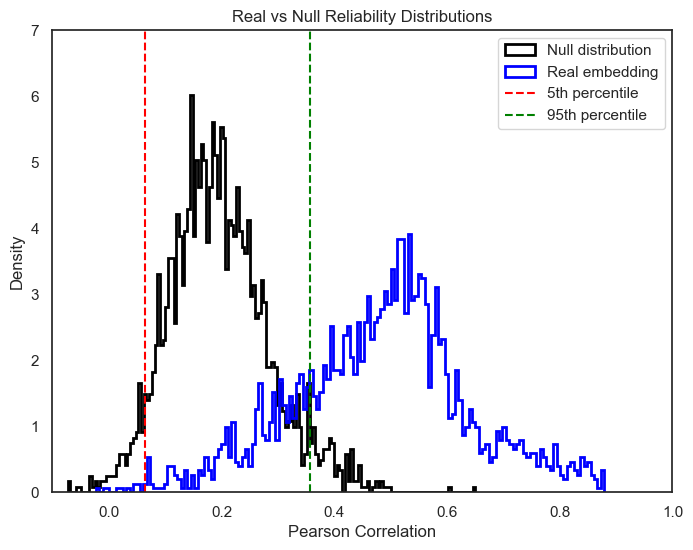

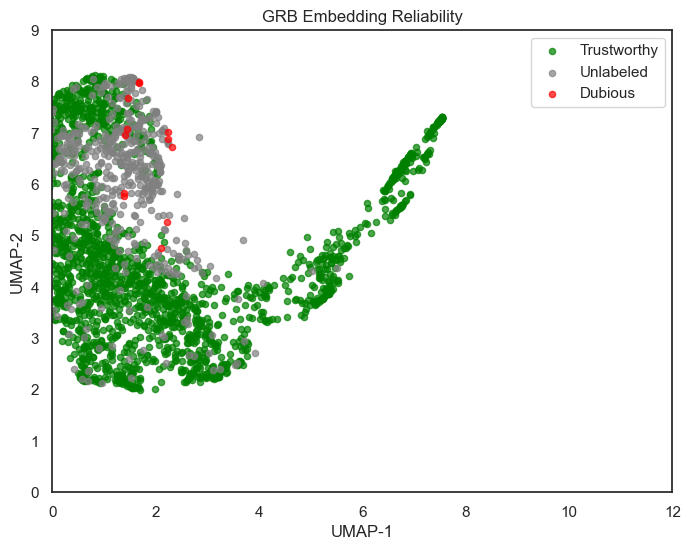

unlabeled_grb [   2   15   19   20   25   29   30   36   39   44   51   62   66   70
   71   72   76   77   87   89   93   95   97   99  109  111  113  128
  133  135  148  150  154  160  166  167  172  178  187  188  190  194
  195  201  202  207  217  223  226  243  247  248  253  261  267  268
  271  282  283  286  289  297  302  304  311  314  315  322  324  328
  339  340  344  354  355  356  365  371  374  377  382  384  393  394
  405  408  409  411  412  418  425  442  445  459  463  464  467  470
  472  473  474  475  477  483  489  498  499  500  506  509  510  512
  521  522  527  528  532  534  538  540  548  552  555  557  561  566
  576  583  584  588  602  605  606  617  619  621  625  629  632  635
  637  650  652  660  665  667  668  677  678  697  700  701  710  718
  723  724  728  739  742  743  752  758  769  773  797  799  800  801
  808  816  819  821  837  842  845  848  868  871  876  880  882  883
  889  891  895  898  921  930  933  938  944  955  961  964  9

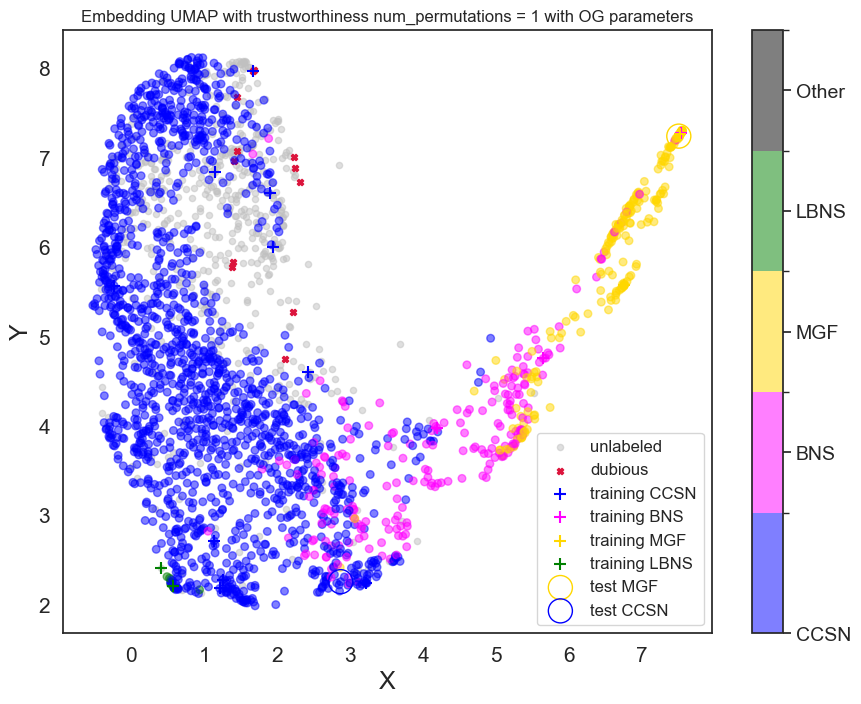

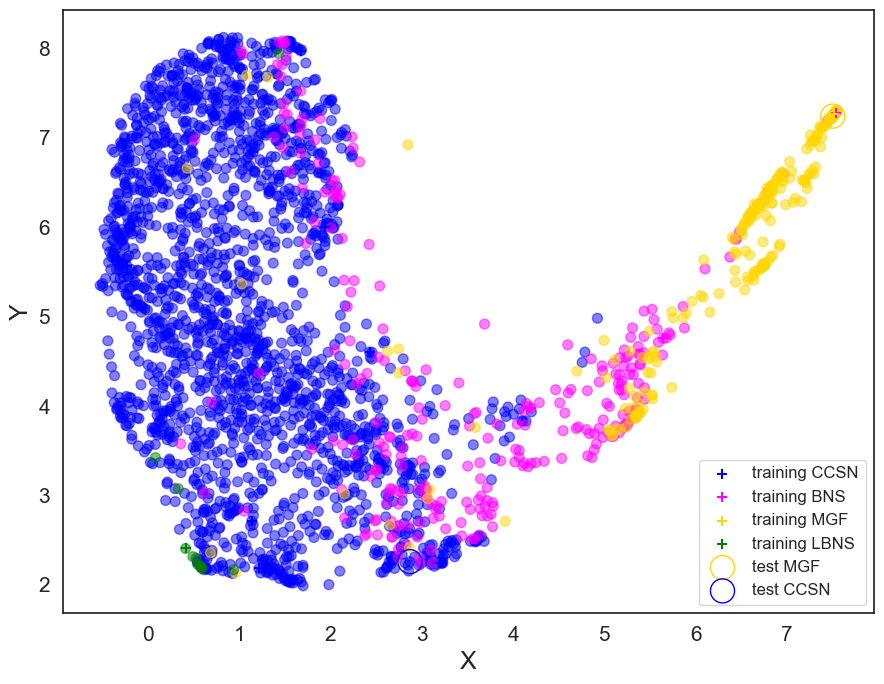

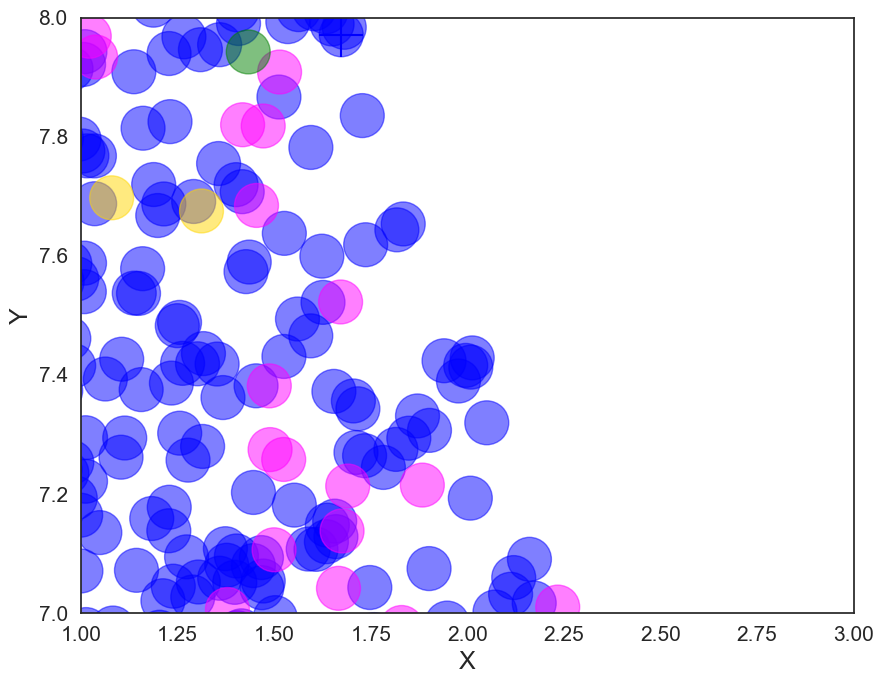

In [5]:
# import sys 
# sys.exit()


print('----------------------------')
print('Building latent space distribution plot for NN = %i'%(NN))
NC = 2

reducer = umap.UMAP(n_neighbors=NN, min_dist=MD, n_components=NC, 
                    metric=M, n_epochs=NEPOCHS, local_connectivity=LOC_CON, 
                    learning_rate=LR,random_state=100)
embedding = reducer.fit_transform(hl)
embeddingT = embedding.T

significativity,max_null_values,max_data_values = get_trustworthiness(hl,embedding) #To import embedding reliability

unlabeled_grb = np.where(significativity == 0)[0]
print('unlabeled_grb',unlabeled_grb)
trustworthy_grb = np.where(significativity == 1)[0]
print('trustworthy_grb',trustworthy_grb)
dubious_grb = np.where(significativity == -1)[0]
print('dubious_grb',dubious_grb)
trust_data = embedding[trustworthy_grb]
print('trust_data',trust_data)

np.save(
    os.path.join('Label Propagation','UMAP',
    'UMAP_VARIABLES_minval5_weightedLoss_Mic_2D.npy'),
    {
        'embedding': embedding,
        'dubious_idx': dubious_grb,
        'trustworthy_idx': trustworthy_grb,
        'unlabeled_idx': unlabeled_grb
    }
)

if args.n_components == 3:
    embedding_dict = {'umap 0' : embeddingT[0],
                      'umap 1' : embeddingT[1],
                      'umap 2' : embeddingT[2]}

if args.n_components == 2:
    embedding_dict = {'umap 0' : embeddingT[0],
                      'umap 1' : embeddingT[1]}   

embedding_df = pd.DataFrame.from_dict(embedding_dict)
# embedding_df['output_label'] = _output_labels_mean
# embedding_df['output_label_std'] = _output_labels_std
embedding_df['rate_CCSN'] = rates_CCSN
embedding_df['rate_BNS'] = rates_BNS
embedding_df['rate_MGF'] = rates_MGF
embedding_df['rate_LBNS'] = rates_LBNS
# embedding_df['label_80'] = label_80
# embedding_df['label_90'] = label_90
embedding_df['label_95'] = label_95
embedding_df['name'] = grb_names


import matplotlib as mpl
cmap = (mpl.colors.ListedColormap(['blue', 'magenta', 'gold', 'green', 'black'])).with_extremes(under='silver', over='silver')
bounds = [0, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

if args.n_components == 3:

    fig = plt.figure()
    ax = plt.axes(projection='3d')
    plt.title('UMAP 3D projection of the hidden layer, T90', fontsize=24)
    sc=ax.scatter3D(embedding[:, 0],
                    embedding[:, 1],
                    embedding[:, 2], c = _output_labels_[:,0], alpha=0.3, cmap='viridis')
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN), 0], 
               embedding[grb_df['name'].isin(GRB_CCSN), 1], 
               embedding[grb_df['name'].isin(GRB_CCSN), 2], color='blue', label='training CCSN',   s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_BNS), 0],
                embedding[grb_df['name'].isin(GRB_BNS), 1],
                embedding[grb_df['name'].isin(GRB_BNS), 2], color='magenta', label='training BNS',    s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF), 0],  
                embedding[grb_df['name'].isin(GRB_MGF), 1],  
                embedding[grb_df['name'].isin(GRB_MGF), 2], color='gold', label='training MGF',   s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_LBNS), 0],
                embedding[grb_df['name'].isin(GRB_LBNS), 1],
                embedding[grb_df['name'].isin(GRB_LBNS), 2], color='green', label='training LBNS', s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF_TEST), 0],  
                embedding[grb_df['name'].isin(GRB_MGF_TEST), 1],  
                embedding[grb_df['name'].isin(GRB_MGF_TEST), 2], label='test MGF', marker='o', facecolor='none', edgecolor='gold', s=100)

    ax.set_xlabel('umap 0')
    ax.set_ylabel('umap 1')
    ax.set_zlabel('umap 2')
    cbar=plt.colorbar(sc)
    cbar.set_label('log(T90)')
    plt.legend(fontsize=12)

if args.n_components == 2:
    _output_labels_std[_output_labels_std == 0] = 0.01

    fig, ax = plt.subplots(figsize=(9, 7))
    
    ax.scatter(embedding[unlabeled_grb, 0],embedding[unlabeled_grb, 1], color='silver',
                                                     s=20, alpha=0.5, label='unlabeled')
    ax.scatter(embedding[dubious_grb, 0],embedding[dubious_grb, 1], color='crimson',marker='X',
                                                     s=20, alpha=1.0, label='dubious')
    sc = ax.scatter(embedding[trustworthy_grb, 0],
                    embedding[trustworthy_grb, 1], c=embedding_df.loc[trustworthy_grb, 'label_95'], s=30, cmap=cmap, norm=norm, alpha=0.5)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN), 0], embedding[grb_df['name'].isin(GRB_CCSN), 1], marker='+', color='blue', label='training CCSN',   s=70)
    ax.scatter(embedding[grb_df['name'].isin(GRB_BNS), 0], embedding[grb_df['name'].isin(GRB_BNS), 1],   marker='+', color='magenta', label='training BNS',       s=70)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF), 0], embedding[grb_df['name'].isin(GRB_MGF), 1],   marker='+', color='gold', label='training MGF',     s=70)
    ax.scatter(embedding[grb_df['name'].isin(GRB_LBNS), 0], embedding[grb_df['name'].isin(GRB_LBNS), 1], marker='+', color='green', label='training LBNS', s=70)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF_TEST), 0], embedding[grb_df['name'].isin(GRB_MGF_TEST), 1], label = 'test MGF',  marker='o', facecolor='none', edgecolor='gold', s=300)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN_TEST), 0], embedding[grb_df['name'].isin(GRB_CCSN_TEST), 1], label = 'test CCSN',  marker='o', facecolor='none', edgecolor='blue', s=300)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels([
    'CCSN',
    'BNS',
    'MGF',
    'LBNS',
    'Other'
    ])
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel('X', fontsize=18)
    ax.set_ylabel('Y', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.title('Embedding UMAP with trustworthiness num_permutations = %i with OG parameters'%(NP))
    # plt.savefig(os.path.join('Label Propagation','UMAP','Final_Embedding_UMAP_num_permutations=%i'%(NP)), dpi = 200)
    plt.show()
 


    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='blue', 
                    s=embedding_df['rate_CCSN']*50, alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='magenta', 
                    s=embedding_df['rate_BNS']*50, alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='gold',    
                         s=embedding_df['rate_MGF']*50 , alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='green',   
                         s=embedding_df['rate_LBNS']*50 , alpha=0.5)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN), 0], embedding[grb_df['name'].isin(GRB_CCSN), 1], 
                           color='blue', label='training CCSN', marker='+',  s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_BNS), 0], embedding[grb_df['name'].isin(GRB_BNS), 1],   
                           color='magenta', label='training BNS',   marker='+',    s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF), 0], embedding[grb_df['name'].isin(GRB_MGF), 1],   
                           color='gold', label='training MGF',  marker='+',   s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_LBNS), 0], embedding[grb_df['name'].isin(GRB_LBNS), 1], 
                           color='green', label='training LBNS',marker='+', s=50)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF_TEST), 0], embedding[grb_df['name'].isin(GRB_MGF_TEST), 1], label = 'test MGF',  marker='o', facecolor='none', edgecolor='gold', s=300)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN_TEST), 0], embedding[grb_df['name'].isin(GRB_CCSN_TEST), 1], label = 'test CCSN',  marker='o', facecolor='none', edgecolor='blue', s=300)
    ax.set_xlabel('X', fontsize=18)
    ax.set_ylabel('Y', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()


    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='blue',
                         s=embedding_df['rate_CCSN']*1000 , alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='magenta', 
                         s=embedding_df['rate_BNS']*1000 , alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='gold',    
                         s=embedding_df['rate_MGF']*1000 , alpha=0.5)
    sc = ax.scatter(embedding_df['umap 0'], embedding_df['umap 1'], c='green',   
                         s=embedding_df['rate_LBNS']*1000 , alpha=0.5)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN), 0], embedding[grb_df['name'].isin(GRB_CCSN), 1], 
                           color='blue', label='training CCSN', marker='+',  s=1000)
    ax.scatter(embedding[grb_df['name'].isin(GRB_BNS), 0], embedding[grb_df['name'].isin(GRB_BNS), 1],   
                           color='magenta', label='training BNS',   marker='+',    s=1000)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF), 0], embedding[grb_df['name'].isin(GRB_MGF), 1],   
                           color='gold', label='training MGF',  marker='+',   s=1000)
    ax.scatter(embedding[grb_df['name'].isin(GRB_LBNS), 0], embedding[grb_df['name'].isin(GRB_LBNS), 1], 
                           color='green', label='training LBNS',marker='+', s=1000)
    ax.scatter(embedding[grb_df['name'].isin(GRB_MGF_TEST), 0], embedding[grb_df['name'].isin(GRB_MGF_TEST), 1], label = 'test MGF',  marker='o', facecolor='none', edgecolor='gold', s=300)
    ax.scatter(embedding[grb_df['name'].isin(GRB_CCSN_TEST), 0], embedding[grb_df['name'].isin(GRB_CCSN_TEST), 1], label = 'test CCSN',  marker='o', facecolor='none', edgecolor='blue', s=300)
    ax.set_xlabel('X', fontsize=18)
    ax.set_ylabel('Y', fontsize=18)
    ax.set_xlim((1.0,3.0))
    ax.set_ylim((7,8))
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.tight_layout()
    plt.show()


    # plt.savefig(os.path.join('Label Propogation','UMAP','Short_minval10_latentspace') dpi=200)      


# In[ ]:


CCSN: 1986
BNS : 284
MGF : 230
LBNS: 12
[ 0.12573859 -0.3553243   1.8874217  ...  0.5363732  -0.11744228
  0.94663996]
[7.201355  5.6349587 6.15683   ... 5.997325  4.0466337 5.35488  ]
Number of GRBs in each class after threshold 0.99
CCSN: 537
BNS : 38
MGF : 14
LBNS: 8
Number of GRBs in each class after threshold 0.9
CCSN: 969
BNS : 97
MGF : 35
LBNS: 10
[[9.70899047e-01 2.70842848e-02 2.01666828e-03 3.37564407e-12]
 [8.64472295e-01 1.24914533e-01 1.06131717e-02 2.77599259e-11]
 [9.74078599e-01 2.58671636e-02 5.42372487e-05 2.47197246e-13]
 ...
 [9.58764032e-01 3.88612140e-02 2.37475442e-03 1.51155407e-11]
 [9.43653906e-02 2.94242538e-01 6.11392072e-01 2.19434300e-12]
 [8.42367742e-01 1.44394995e-01 1.32372632e-02 3.66583598e-11]]


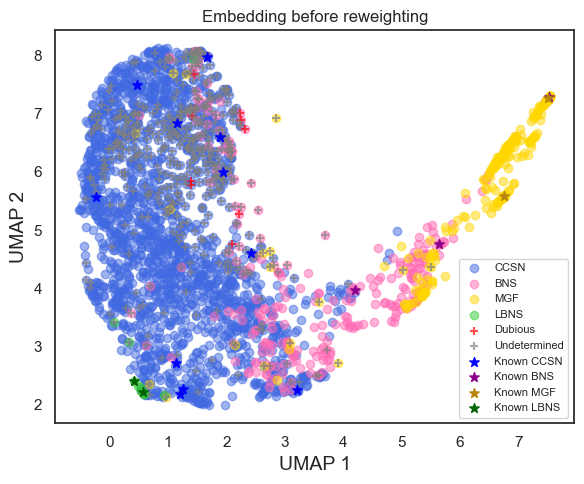

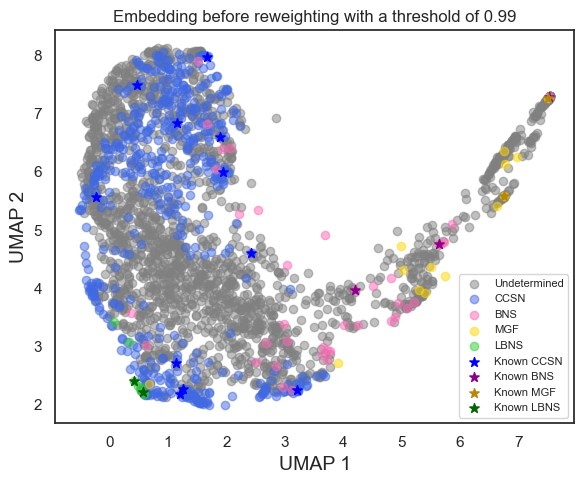

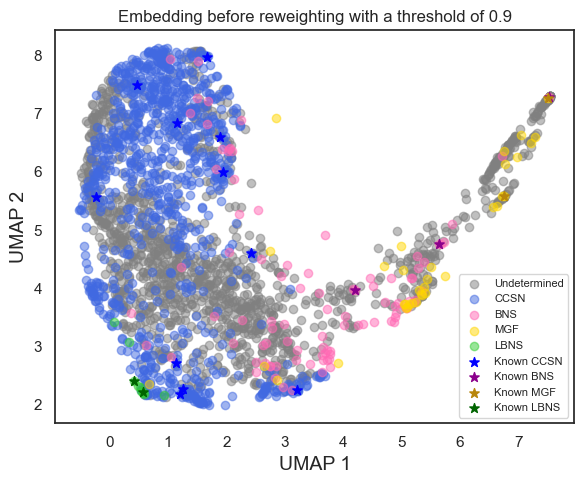

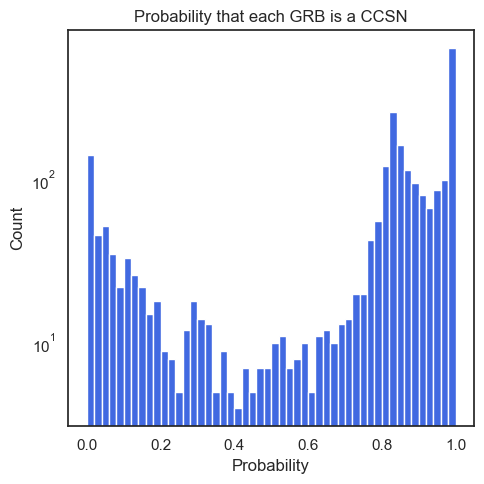

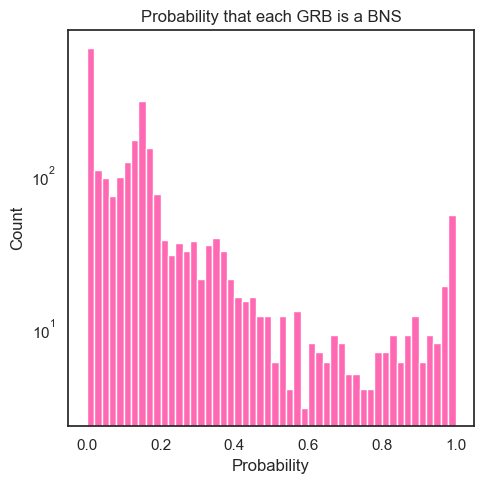

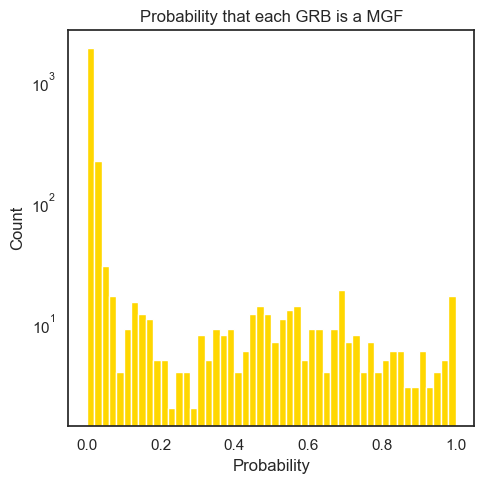

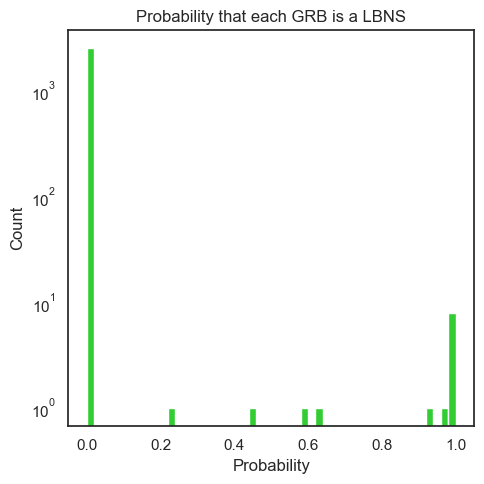

In [7]:
#Plot embedding to show how many of each class there are based on probabilty.
#We want to loop through all rows of output_proba and classify each GRB with the highest probability

labels = np.argmax(output_proba, axis=1)

grb_umap2d =  embeddingT 

#print number of events in each class
print("CCSN:", np.sum(labels == 0))
print("BNS :", np.sum(labels == 1))
print("MGF :", np.sum(labels == 2))
print("LBNS:", np.sum(labels == 3))

print(grb_umap2d.T[labels == 0, 0])
print(grb_umap2d.T[labels == 0, 1])

grb_umap2d_T = grb_umap2d.T 
grb_df['2dumap1'] = grb_umap2d_T[:,0]
grb_df['2dumap2'] = grb_umap2d_T[:,1]
#Plot embedding

plt.figure(figsize=(6,5))
plt.scatter(grb_umap2d_T[labels == 0, 0], grb_umap2d_T[labels == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels == 1, 0], grb_umap2d_T[labels == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels == 2, 0], grb_umap2d_T[labels == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels == 3, 0], grb_umap2d_T[labels == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)
plt.scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious", color = "red", marker = '+',alpha = 0.7)
plt.scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "gray", marker = '+',alpha = 0.7)

plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(loc = "lower right", fontsize=8)
plt.title('Embedding before reweighting')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Embedding_before_reweighting'), dpi = 300)

#Plot embedding with 99% thershold
max_val = np.max(output_proba, axis =1)
threshold_99 = 0.99
labels_99 = np.argmax(output_proba, axis=1)
labels_99[max_val < threshold_99] = -1

#Print number of GRB in each class after threshold
labels_99_CCSN = np.sum(labels_99 == 0)
labels_99_BNS = np.sum(labels_99 == 1)
labels_99_MGF = np.sum(labels_99 == 2)
labels_99_LBNS = np.sum(labels_99 == 3)
print(f'Number of GRBs in each class after threshold {threshold_99}')
print("CCSN:", np.sum(labels_99 == 0))
print("BNS :", np.sum(labels_99 == 1))
print("MGF :", np.sum(labels_99 == 2))
print("LBNS:", np.sum(labels_99 == 3))


#Plot embedding with threshold

plt.figure(figsize=(6, 5))

#plot undetermined points
plt.scatter(grb_umap2d_T[labels_99 == -1, 0], grb_umap2d_T[labels_99 == -1, 1], label="Undetermined", color = "gray", alpha = 0.5)

#plot grbs 
plt.scatter(grb_umap2d_T[labels_99 == 0, 0], grb_umap2d_T[labels_99 == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_99 == 1, 0], grb_umap2d_T[labels_99 == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_99 == 2, 0], grb_umap2d_T[labels_99 == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_99 == 3, 0], grb_umap2d_T[labels_99 == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)

#plot know grbs
plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(fontsize=8, loc = 'lower right')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.title(f'Embedding before reweighting with a threshold of {threshold_99}')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new',f'Embedding_before_reweighting_threshold={threshold_99}.png'), dpi = 200)

#Plot for threshold of 90%
max_val = np.max(output_proba, axis =1)
threshold_90 = 0.90
labels_90 = np.argmax(output_proba, axis=1)
labels_90[max_val < threshold_90] = -1

#Print number of GRB in each class after threshold
print(f'Number of GRBs in each class after threshold {threshold_90}')
print("CCSN:", np.sum(labels_90 == 0))
print("BNS :", np.sum(labels_90 == 1))
print("MGF :", np.sum(labels_90 == 2))
print("LBNS:", np.sum(labels_90 == 3))

print(output_proba)

#Plot embedding with threshold

plt.figure(figsize=(6, 5))

#plot undetermined points
plt.scatter(grb_umap2d_T[labels_90 == -1, 0], grb_umap2d_T[labels_90 == -1, 1], label="Undetermined", color = "gray", alpha = 0.5)

#plot grbs 
plt.scatter(grb_umap2d_T[labels_90 == 0, 0], grb_umap2d_T[labels_90 == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_90 == 1, 0], grb_umap2d_T[labels_90 == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_90 == 2, 0], grb_umap2d_T[labels_90 == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_90 == 3, 0], grb_umap2d_T[labels_90 == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)

#plot know grbs
plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(fontsize=8, loc = 'lower right')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.title(f'Embedding before reweighting with a threshold of {threshold_90}')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new',f'Embedding_before_reweighting_threshold={threshold_90}.png'), dpi = 200)
#Plot histograms of probability for each progenitor
plt.figure(figsize=(5,5))
plt.hist(output_proba[:,0], bins=50, color = "royalblue")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a CCSN')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_CCNS_B4_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba[:,1], bins=50, color = "hotpink")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a BNS')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_BNS_B4_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba[:,2], bins=50, color = "gold")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a MGF')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_MGF_B4_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba[:,3], bins=50, color = "limegreen")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a LBNS')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_LBNS_B4_RW'), dpi = 300)

plt.show()

[[9.70899047e-01 2.70842848e-02 2.01666828e-03 3.37564407e-12]
 [8.64472295e-01 1.24914533e-01 1.06131717e-02 2.77599259e-11]
 [9.74078599e-01 2.58671636e-02 5.42372487e-05 2.47197246e-13]
 ...
 [9.58764032e-01 3.88612140e-02 2.37475442e-03 1.51155407e-11]
 [9.43653906e-02 2.94242538e-01 6.11392072e-01 2.19434300e-12]
 [8.42367742e-01 1.44394995e-01 1.32372632e-02 3.66583598e-11]]
CCSN: 1968
BNS : 493
MGF : 37
LBNS: 14
Output probabilities after re-weighting:
[[8.00193498e-01 2.76248465e-02 2.48917277e-04 1.43580302e-10]
 [7.12478926e-01 1.27407640e-01 1.30998331e-03 1.18074609e-09]
 [8.02814015e-01 2.63834334e-02 6.69450123e-06 1.05143358e-11]
 ...
 [7.90192087e-01 3.96368256e-02 2.93115834e-04 6.42927349e-10]
 [7.77738656e-02 3.00115177e-01 7.54640966e-02 9.33346121e-11]
 [6.94260842e-01 1.47276902e-01 1.63387481e-03 1.55923381e-09]]
Sum of output probabilities for each point after re-weighting: [0.82806726 0.84119655 0.82920414 ... 0.83012203 0.45335314 0.84317162]


Text(0.5, 1.0, 'Sum of label probabilities after re-weighting')

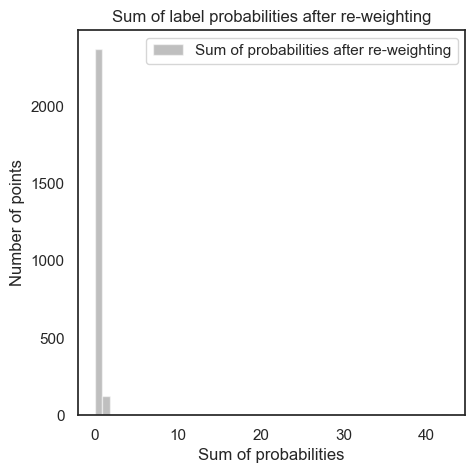

In [8]:
#Add known percentages to adjust N
#old percentages
# k_ccsn = 0.75
# k_bns = 0.18
# k_mgf = 0.02
# k_lbns = 0.05

#New percentages from Eric on 2/23/2026
k_ccsn = 0.60
k_bns = 0.19
k_mgf = 0.01
k_lbns = 0.20 #The real percentage for long grbs is 20 I need to add healium star mergers

alpha_ccsn = k_ccsn / proba_sum[0] * np.sum(proba_sum)
alpha_bns = k_bns / proba_sum[1] * np.sum(proba_sum)   
alpha_mgf = k_mgf / proba_sum[2] * np.sum(proba_sum)
alpha_lbns = k_lbns / proba_sum[3] * np.sum(proba_sum)

#Multiply To get value based on known precentages
output_proba_percent = label_spread.label_distributions_
print(output_proba_percent)
output_proba_percent[:,0] *= alpha_ccsn
output_proba_percent[:,1] *= alpha_bns
output_proba_percent[:,2] *= alpha_mgf
output_proba_percent[:,3] *= alpha_lbns

labels_proba = np.argmax(output_proba_percent, axis=1)

print("CCSN:", np.sum(labels_proba == 0))
print("BNS :", np.sum(labels_proba == 1))
print("MGF :", np.sum(labels_proba == 2))
print("LBNS:", np.sum(labels_proba == 3))

print('Output probabilities after re-weighting:')
print(output_proba_percent)
# check row-wise sum to 1
event_sum_reweighted = np.sum(output_proba_percent, axis=1)
print('Sum of output probabilities for each point after re-weighting:', event_sum_reweighted) #Check if 1 should not be

#histo of the re-weighted probabilities
plt.figure(figsize=(5, 5))
plt.hist(event_sum_reweighted, bins=50, color='gray', alpha=0.5, label='Sum of probabilities after re-weighting')
plt.legend()
plt.xlabel('Sum of probabilities')
plt.ylabel('Number of points')
plt.title('Sum of label probabilities after re-weighting')

In [9]:
# now I wan to reweight each row to sum to 1
output_proba_norm = output_proba / event_sum_reweighted[:, np.newaxis]

print('Output probabilities after re-normalizing:')
print(output_proba_norm)

#verify row-wise sum to 1
event_sum_renormalized = np.sum(output_proba_norm, axis=1)
print('Sum of output probabilities for each point after re-normalizing (should be 1):', event_sum_renormalized)

# verify golabl sum to number of points
#Look at how similar this is to original and what we expect
proba_sum_renormalized = np.sum(output_proba_norm, axis=0)
print('Sum of output probabilities for each class after re-normalizing:')
print('CCSN:', proba_sum_renormalized[0])
print('BNS:', proba_sum_renormalized[1])
print('MGF:', proba_sum_renormalized[2])
print('LBNS:', proba_sum_renormalized[3])

print('total sum after re-normalizing (should be number of points):', np.sum(proba_sum_renormalized))
print('should be equal to TOT_EVENTS:', TOT_EVENTS)

Output probabilities after re-normalizing:
[[9.66338768e-01 3.33606311e-02 3.00600311e-04 1.73392076e-10]
 [8.46982701e-01 1.51460012e-01 1.55728565e-03 1.40365066e-09]
 [9.68174149e-01 3.18177780e-02 8.07340543e-06 1.26800329e-11]
 ...
 [9.51898708e-01 4.77481914e-02 3.53099693e-04 7.74497395e-10]
 [1.71552502e-01 6.61989851e-01 1.66457646e-01 2.05876179e-10]
 [8.23392089e-01 1.74670136e-01 1.93777254e-03 1.84924845e-09]]
Sum of output probabilities for each point after re-normalizing (should be 1): [1. 1. 1. ... 1. 1. 1.]
Sum of output probabilities for each class after re-normalizing:
CCSN: 1816.3711413301753
BNS: 606.1688775081311
MGF: 74.39283305236198
LBNS: 15.067148109326833
total sum after re-normalizing (should be number of points): 2511.999999999995
should be equal to TOT_EVENTS: 2512.0


CCSN: 1968
BNS : 493
MGF : 37
LBNS: 14
[ 0.12573859 -0.3553243   1.8874217  ...  0.5363732  -0.11744228
  0.94663996]
[7.201355  5.6349587 6.15683   ... 5.997325  4.0466337 5.35488  ]
Number of GRBs in each class after threshold 0.99
CCSN: 520
BNS : 55
MGF : 7
LBNS: 10
Number of GRBs in each class after threshold 0.9
CCSN: 912
BNS : 130
MGF : 15
LBNS: 14


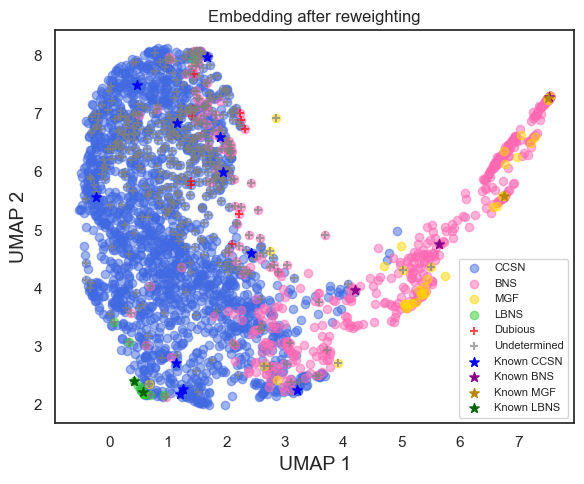

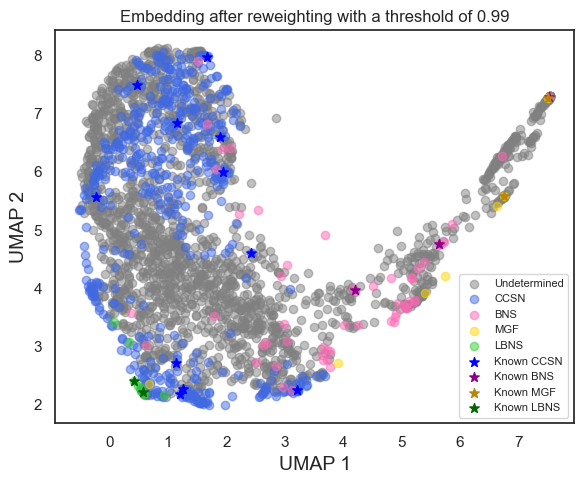

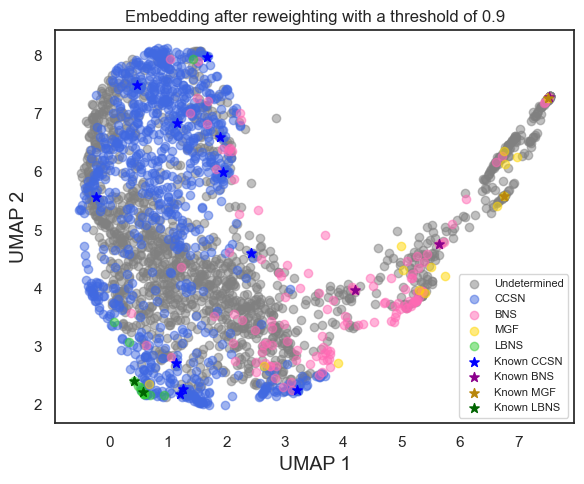

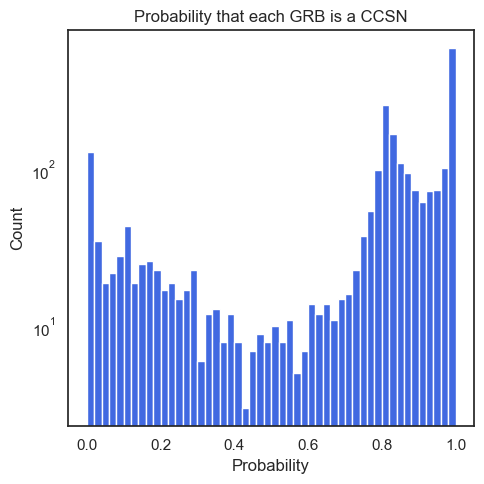

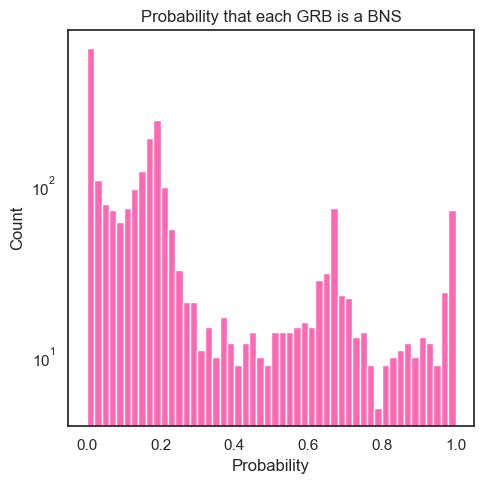

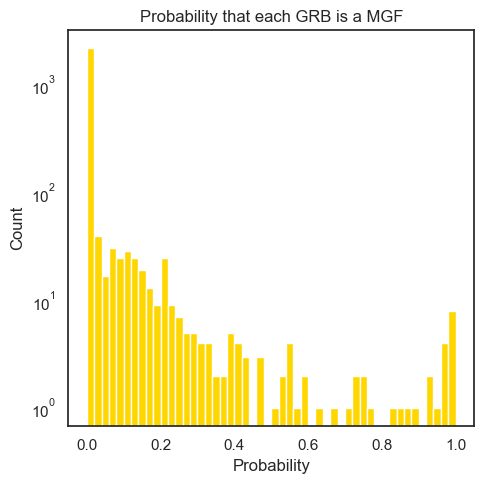

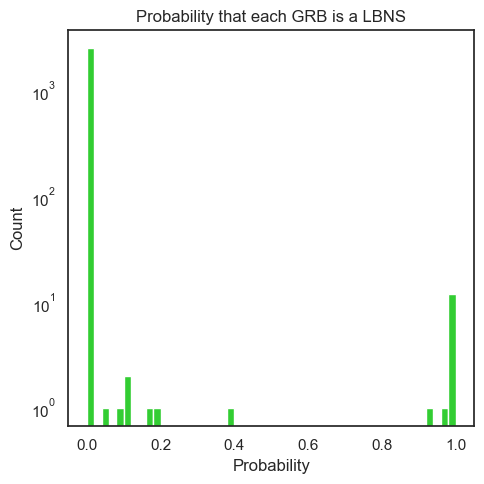

In [10]:
#Plot embedding to show how many of each class there are based on probabilty.
#We want to loop through all rows of output_proba_norm and classify each GRB with the highest probability

labels_norm = np.argmax(output_proba_norm, axis=1)

#print number of events in each class
print("CCSN:", np.sum(labels_norm == 0))
print("BNS :", np.sum(labels_norm == 1))
print("MGF :", np.sum(labels_norm == 2))
print("LBNS:", np.sum(labels_norm == 3))

print(grb_umap2d_T[labels_norm == 0, 0])
print(grb_umap2d_T[labels_norm == 0, 1])

#Plot embedding
grb_umap2d_T = grb_umap2d_T 

plt.figure(figsize=(6,5))
plt.scatter(grb_umap2d_T[labels_norm == 0, 0], grb_umap2d_T[labels_norm == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm == 1, 0], grb_umap2d_T[labels_norm == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm == 2, 0], grb_umap2d_T[labels_norm == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm == 3, 0], grb_umap2d_T[labels_norm == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)
plt.scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious", color = "red", marker = '+',alpha = 0.7)
plt.scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "gray", marker = '+',alpha = 0.7)

plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(loc = "lower right", fontsize=8)
plt.title('Embedding after reweighting')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Embedding_after_reweighting'), dpi = 300)

#Plot embedding with 99% thershold
max_val = np.max(output_proba_norm, axis =1)
labels_norm_99 = np.argmax(output_proba_norm, axis=1)
labels_norm_99[max_val < threshold_99] = -1

#Print number of GRB in each class after threshold
labels_norm_99_CCSN = np.sum(labels_norm_99 == 0)
labels_norm_99_BNS = np.sum(labels_norm_99 == 1)
labels_norm_99_MGF = np.sum(labels_norm_99 == 2)
labels_norm_99_LBNS = np.sum(labels_norm_99 == 3)
print(f'Number of GRBs in each class after threshold {threshold_99}')
print("CCSN:", np.sum(labels_norm_99 == 0))
print("BNS :", np.sum(labels_norm_99 == 1))
print("MGF :", np.sum(labels_norm_99 == 2))
print("LBNS:", np.sum(labels_norm_99 == 3))


#Plot embedding with threshold

plt.figure(figsize=(6, 5))

#plot undetermined points
plt.scatter(grb_umap2d_T[labels_norm_99 == -1, 0], grb_umap2d_T[labels_norm_99 == -1, 1], label="Undetermined", color = "gray", alpha = 0.5)

#plot grbs 
plt.scatter(grb_umap2d_T[labels_norm_99 == 0, 0], grb_umap2d_T[labels_norm_99 == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_99 == 1, 0], grb_umap2d_T[labels_norm_99 == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_99 == 2, 0], grb_umap2d_T[labels_norm_99 == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_99 == 3, 0], grb_umap2d_T[labels_norm_99 == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)

#plot know grbs
plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(fontsize=8, loc = 'lower right')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.title(f'Embedding after reweighting with a threshold of {threshold_99}')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new',f'Embedding_after_reweighting_threshold={threshold_99}.png'), dpi = 200)

#Plot for threshold of 90%
max_val = np.max(output_proba_norm, axis =1)
labels_norm_90 = np.argmax(output_proba_norm, axis=1)
labels_norm_90[max_val < threshold_90] = -1

#Print number of GRB in each class after threshold
print(f'Number of GRBs in each class after threshold {threshold_90}')
print("CCSN:", np.sum(labels_norm_90 == 0))
print("BNS :", np.sum(labels_norm_90 == 1))
print("MGF :", np.sum(labels_norm_90 == 2))
print("LBNS:", np.sum(labels_norm_90 == 3))


#Plot embedding with threshold

plt.figure(figsize=(6, 5))

#plot undetermined points
plt.scatter(grb_umap2d_T[labels_norm_90 == -1, 0], grb_umap2d_T[labels_norm_90 == -1, 1], label="Undetermined", color = "gray", alpha = 0.5)

#plot grbs 
plt.scatter(grb_umap2d_T[labels_norm_90 == 0, 0], grb_umap2d_T[labels_norm_90 == 0, 1,], label="CCSN", color = "royalblue", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_90 == 1, 0], grb_umap2d_T[labels_norm_90 == 1, 1,], label="BNS", color = "hotpink", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_90 == 2, 0], grb_umap2d_T[labels_norm_90 == 2, 1,], label="MGF", color = "gold", alpha = 0.5)
plt.scatter(grb_umap2d_T[labels_norm_90 == 3, 0], grb_umap2d_T[labels_norm_90 == 3, 1,], label="LBNS", color = "limegreen", alpha = 0.5)

#plot know grbs
plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='blue', marker = '*', s=50, label="Known CCSN")
plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='darkmagenta', marker = '*', s=50, label="Known BNS")
plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkgoldenrod', marker = '*', s=50, label="Known MGF")
plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='darkgreen', marker = '*', s=50, label="Known LBNS")
plt.legend(fontsize=8, loc = 'lower right')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.title(f'Embedding after reweighting with a threshold of {threshold_90}')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new',f'Embedding_after_reweighting_threshold={threshold_90}.png'), dpi = 200)
#Plot histograms of probability for each progenitor
plt.figure(figsize=(5,5))
plt.hist(output_proba_norm[:,0], bins=50, color = "royalblue")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a CCSN')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_CCNS_aft_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba_norm[:,1], bins=50, color = "hotpink")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a BNS')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_BNS_aft_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba_norm[:,2], bins=50, color = "gold")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a MGF')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_MGF_aft_RW'), dpi = 300)

plt.figure(figsize=(5,5))
plt.hist(output_proba_norm[:,3], bins=50, color = "limegreen")
plt.yscale('log')
plt.xlabel('Probability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Probability that each GRB is a LBNS')
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_LBNS_aft_RW'), dpi = 300)

plt.show()

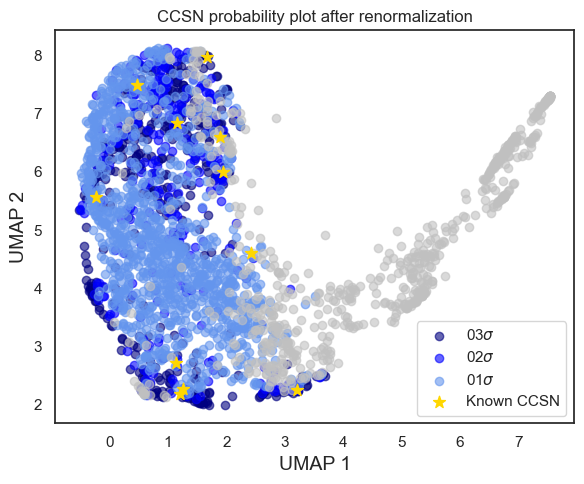

In [11]:
#I want to plot only CCSN and distribute the plot by colors based on probability
ccsn_proba = output_proba_norm[:,0]

ccsn_m_3s = np.where((ccsn_proba >= 0.997) & (ccsn_proba < 1.0))[0]
ccsn_m_2s = np.where((ccsn_proba >= 0.95) & (ccsn_proba < 0.997))[0]
ccsn_m_1s  = np.where((ccsn_proba >= 0.68) & (ccsn_proba < 0.95))[0]
ccsn_m_0s  = np.where((ccsn_proba < 0.68))[0]


plt.figure(figsize=(6, 5))
plt.scatter(grb_umap2d[0, ccsn_m_3s],  grb_umap2d[1, ccsn_m_3s],  color="navy",  label="03$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, ccsn_m_2s], grb_umap2d[1, ccsn_m_2s], color="blue", label="02$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, ccsn_m_1s], grb_umap2d[1, ccsn_m_1s], color="cornflowerblue",     label="01$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, ccsn_m_0s], grb_umap2d[1, ccsn_m_0s], color="silver", alpha=0.6)

plt.scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='gold', marker = '*', s=80, label="Known CCSN")
plt.title('CCSN probability plot after renormalization')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_map_CCSN'),dpi = 200)
plt.show()

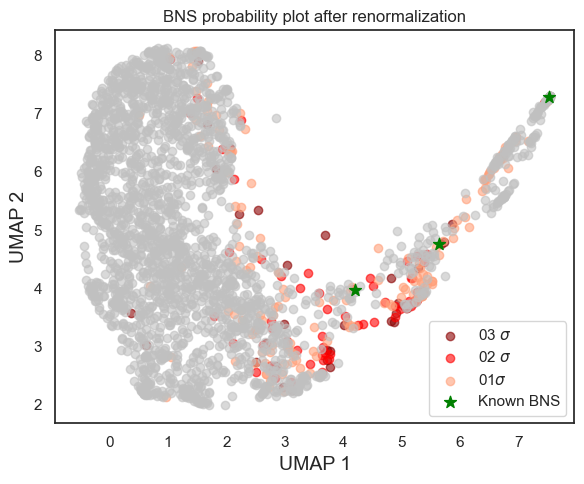

In [12]:
#I want to plot only BNS and distribute the plot by colors based on probability
bns_proba = output_proba_norm[:,1]

bns_m_3s = np.where((bns_proba >= 0.997) & (bns_proba < 1.0))[0]
bns_m_2s = np.where((bns_proba >= 0.95) & (bns_proba < 0.997))[0]
bns_m_1s  = np.where((bns_proba >= 0.68) & (bns_proba < 0.95))[0]
bns_m_0s  = np.where((bns_proba < 0.68))[0]


plt.figure(figsize=(6, 5))
plt.scatter(grb_umap2d[0, bns_m_3s],  grb_umap2d[1, bns_m_3s],  color="darkred",  label="03 $\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, bns_m_2s], grb_umap2d[1, bns_m_2s], color="red", label="02 $\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, bns_m_1s], grb_umap2d[1, bns_m_1s], color="lightsalmon",     label="01$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, bns_m_0s], grb_umap2d[1, bns_m_0s], color="silver", alpha=0.6)

plt.scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='green', marker = '*', s=80, label="Known BNS")
plt.title('BNS probability plot after renormalization')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_map_BNS'),dpi = 200)
plt.show()

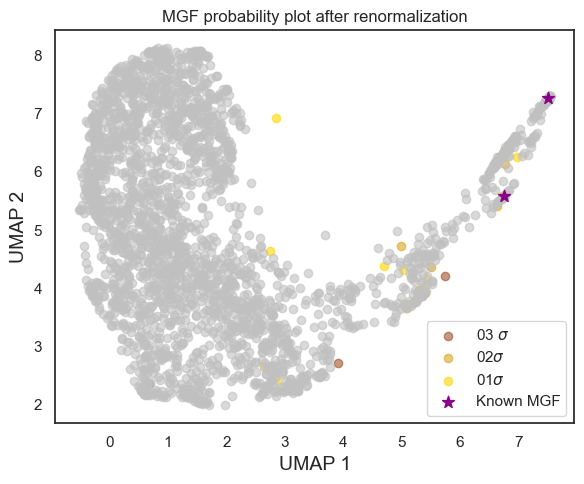

In [13]:
#I want to plot only MGF and distribute the plot by colors based on probability
mgf_proba = output_proba_norm[:,2]

mgf_m_3s = np.where((mgf_proba >= 0.997) & (mgf_proba < 1.0))[0]
mgf_m_2s = np.where((mgf_proba >= 0.95) & (mgf_proba < 0.997))[0]
mgf_m_1s  = np.where((mgf_proba >= 0.68) & (mgf_proba < 0.95))[0]
mgf_m_0s  = np.where((mgf_proba < 0.68))[0]


plt.figure(figsize=(6, 5))
plt.scatter(grb_umap2d[0, mgf_m_3s],  grb_umap2d[1, mgf_m_3s],  color="sienna",  label="03 $\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, mgf_m_2s], grb_umap2d[1, mgf_m_2s], color="goldenrod", label="02$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, mgf_m_1s], grb_umap2d[1, mgf_m_1s], color="gold",     label="01$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, mgf_m_0s], grb_umap2d[1, mgf_m_0s], color="silver", alpha=0.6)

plt.scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='darkmagenta', marker = '*', s=80, label="Known MGF")
plt.title('MGF probability plot after renormalization')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_map_MGF'),dpi = 200)
plt.show()

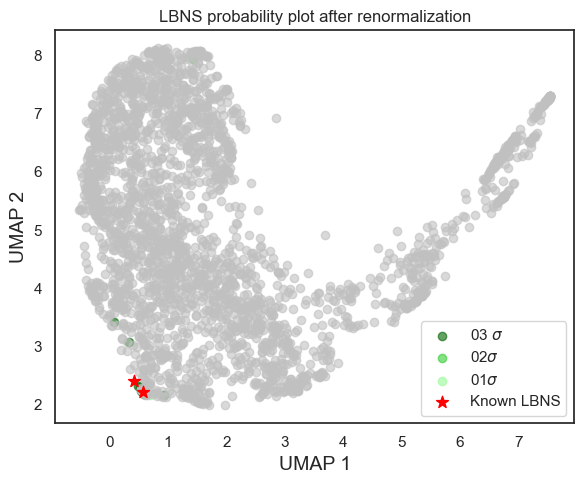

In [14]:
#I want to plot only LBNS and distribute the plot by colors based on probability
lbns_proba = output_proba_norm[:,3]

lbns_m_3s = np.where((lbns_proba >= 0.997) & (lbns_proba < 1.0))[0]
lbns_m_2s = np.where((lbns_proba >= 0.95) & (lbns_proba < 0.997))[0]
lbns_m_1s  = np.where((lbns_proba >= 0.68) & (lbns_proba < 0.95))[0]
lbns_m_0s  = np.where((lbns_proba < 0.68))[0]


plt.figure(figsize=(6, 5))
plt.scatter(grb_umap2d[0, lbns_m_3s],  grb_umap2d[1, lbns_m_3s],  color="darkgreen",  label=r"03 $\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, lbns_m_2s], grb_umap2d[1, lbns_m_2s], color="limegreen", label="02$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, lbns_m_1s], grb_umap2d[1, lbns_m_1s], color="palegreen",     label="01$\sigma$", alpha=0.6)
plt.scatter(grb_umap2d[0, lbns_m_0s], grb_umap2d[1, lbns_m_0s], color="silver", alpha=0.6)

plt.scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='red', marker = '*', s=80, label="Known LBNS")
plt.title('LBNS probability plot after renormalization')
plt.xlabel('UMAP 1', fontsize=14)
plt.ylabel('UMAP 2', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join('Paper_2-10-2025_new','Prob_map_LBNS'),dpi = 200)
plt.show()

C:\Users\skyes\AppData\Local\Temp\ipykernel_47008\2085253200.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


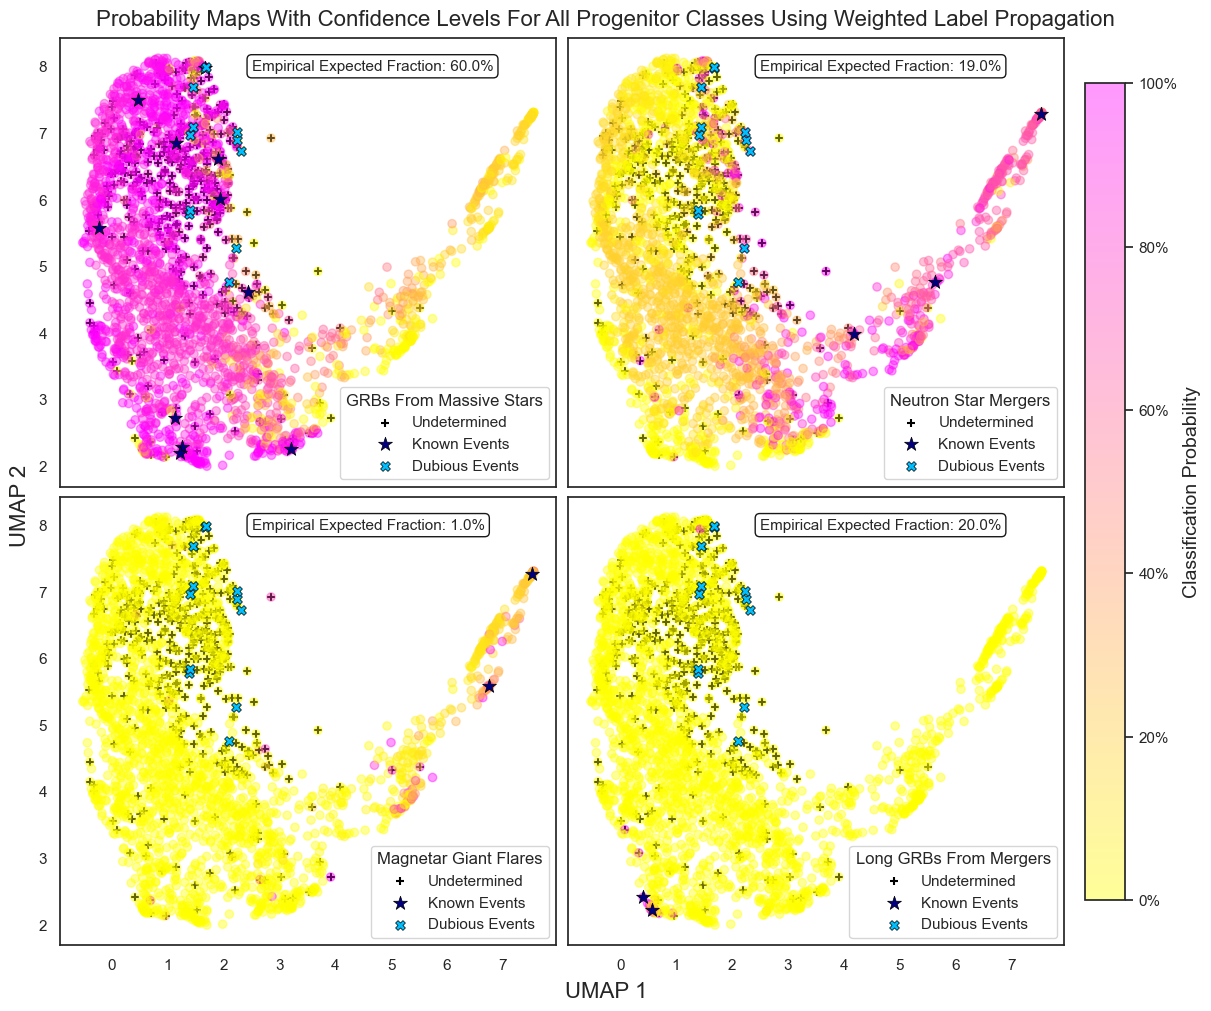

In [15]:
#This is the same plot but with a color map as the legend
import matplotlib.ticker as mticker
#Four subplots in one big plot
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(12,10),constrained_layout=True)
fig.subplots_adjust(
    wspace=0.0,   
    hspace=0.0   
)

#CCSN 
axes[0,0].scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "black", marker = '+')
sc = axes[0,0].scatter(grb_umap2d[0],  grb_umap2d[1], c=ccsn_proba, cmap='spring_r', vmin=0, vmax=1, alpha=0.4)
axes[0,0].scatter(grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_CCSN)]['2dumap2'], c='navy', marker = '*', s=110,edgecolor='black', linewidth=0.5, label="Known Events")
axes[0,0].scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious Events", color = "deepskyblue", marker = 'X',edgecolor='black', linewidth=0.5, s=50)
axes[0,0].legend(title="GRBs From Massive Stars", loc='lower right')
axes[0,0].annotate(f'Empirical Expected Fraction: {k_ccsn*100}%',xy=(2.5, 8),xycoords='data',fontsize=11, ha='left',
    va='center',bbox=dict( boxstyle="round,pad=0.3",fc="white",ec="black",alpha=0.9))
# axes[0,0].set_facecolor('dimgray')
#BNS
axes[0,1].scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "black", marker = '+')
sc = axes[0,1].scatter(grb_umap2d[0],  grb_umap2d[1], c=bns_proba, cmap='spring_r', vmin=0, vmax=1, alpha=0.4)
axes[0,1].scatter(grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_BNS)]['2dumap2'], c='navy', marker = '*',edgecolor='black', linewidth=0.5,  s=110, label="Known Events")
axes[0,1].scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious Events", color = "deepskyblue", marker = 'X',edgecolor='black', linewidth=0.5, s=50)
axes[0,1].legend(title="Neutron Star Mergers", loc='lower right')
axes[0,1].annotate(f'Empirical Expected Fraction: {k_bns*100}%',xy=(2.5, 8),xycoords='data',fontsize=11, ha='left',
    va='center',bbox=dict( boxstyle="round,pad=0.3",fc="white",ec="black",alpha=0.9))
# axes[0,1].set_facecolor('silver')
#MGF
axes[1,0].scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "black", marker = '+')
sc = axes[1,0].scatter(grb_umap2d[0],  grb_umap2d[1], c=mgf_proba, cmap='spring_r', vmin=0, vmax=1, alpha=0.4)
axes[1,0].scatter(grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_MGF)]['2dumap2'], c='navy', marker = '*', s=110,edgecolor='black', linewidth=0.5, label="Known Events")
axes[1,0].scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious Events", color = "deepskyblue", marker = 'X',edgecolor='black', linewidth=0.5, s=50)
axes[1,0].legend(title="Magnetar Giant Flares", loc='lower right')
axes[1,0].annotate(f'Empirical Expected Fraction: {k_mgf*100}%',xy=(2.5, 8),xycoords='data',fontsize=11, ha='left',
    va='center',bbox=dict( boxstyle="round,pad=0.3",fc="white",ec="black",alpha=0.9))
# axes[1,0].set_facecolor('lavender')
#LBNS
axes[1,1].scatter(grb_umap2d_T[unlabeled_grb, 0], grb_umap2d_T[unlabeled_grb, 1], label="Undetermined", color = "black", marker = '+')
sc = axes[1,1].scatter(grb_umap2d[0],  grb_umap2d[1], c=lbns_proba, cmap='spring_r', vmin=0, vmax=1, alpha=0.4)
axes[1,1].scatter(grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap1'], grb_df[grb_df['name'].isin(GRB_LBNS)]['2dumap2'], c='navy', marker = '*', s=110,edgecolor='black', linewidth=0.5, label="Known Events")
axes[1,1].scatter(grb_umap2d_T[dubious_grb, 0], grb_umap2d_T[dubious_grb, 1], label="Dubious Events", color = "deepskyblue", marker = 'X',edgecolor='black', linewidth=0.5, s=50)
axes[1,1].legend(title="Long GRBs From Mergers", loc='lower right')
axes[1,1].annotate(f'Empirical Expected Fraction: {k_lbns*100}%',xy=(2.5, 8),xycoords='data',fontsize=11, ha='left',
    va='center',bbox=dict( boxstyle="round,pad=0.3",fc="white",ec="black",alpha=0.9))
# axes[1,1].set_facecolor('white')

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), location='right', shrink=0.9, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
cbar.set_label("Classification Probability", fontsize=14)
fig.supxlabel("UMAP 1", fontsize=16)
fig.supylabel("UMAP 2", fontsize=16)
fig.suptitle("Probability Maps With Confidence Levels For All Progenitor Classes Using Weighted Label Propagation", fontsize=16)
plt.savefig(os.path.join('Paper_2-10-2025_new','Confidence_Level_Map'),dpi = 200)
plt.show()

In [16]:
print('Number of GRBs in each class before weight')
print("CCSN:", np.sum(labels == 0))
print("BNS :", np.sum(labels == 1))
print("MGF :", np.sum(labels == 2))
print("LBNS:", np.sum(labels == 3))

print(f'Number of GRBs in each class after threshold {threshold_99}')
print("CCSN:", np.sum(labels_99 == 0))
print("BNS :", np.sum(labels_99 == 1))
print("MGF :", np.sum(labels_99 == 2))
print("LBNS:", np.sum(labels_99 == 3))
print(f'Number of GRBs in each class after threshold {threshold_90}')
print("CCSN:", np.sum(labels_90 == 0))
print("BNS :", np.sum(labels_90 == 1))
print("MGF :", np.sum(labels_90 == 2))
print("LBNS:", np.sum(labels_90 == 3))
print('Number of GRBs in each class after weight')
print("CCSN:", np.sum(labels_norm == 0))
print("BNS :", np.sum(labels_norm == 1))
print("MGF :", np.sum(labels_norm == 2))
print("LBNS:", np.sum(labels_norm == 3))

print(f'Number of GRBs in each class after threshold {threshold_99}')
print("CCSN:", np.sum(labels_norm_99 == 0))
print("BNS :", np.sum(labels_norm_99 == 1))
print("MGF :", np.sum(labels_norm_99 == 2))
print("LBNS:", np.sum(labels_norm_99 == 3))
print(f'Number of GRBs in each class after threshold {threshold_90}')
print("CCSN:", np.sum(labels_norm_90 == 0))
print("BNS :", np.sum(labels_norm_90 == 1))
print("MGF :", np.sum(labels_norm_90 == 2))
print("LBNS:", np.sum(labels_norm_90 == 3))

Number of GRBs in each class before weight
CCSN: 1986
BNS : 284
MGF : 230
LBNS: 12
Number of GRBs in each class after threshold 0.99
CCSN: 537
BNS : 38
MGF : 14
LBNS: 8
Number of GRBs in each class after threshold 0.9
CCSN: 969
BNS : 97
MGF : 35
LBNS: 10
Number of GRBs in each class after weight
CCSN: 1968
BNS : 493
MGF : 37
LBNS: 14
Number of GRBs in each class after threshold 0.99
CCSN: 520
BNS : 55
MGF : 7
LBNS: 10
Number of GRBs in each class after threshold 0.9
CCSN: 912
BNS : 130
MGF : 15
LBNS: 14
